# Semester Assignment 2

## Dynamic surrogate model for the pervaporation module

The goal is to replace a slow, rigorous process model with a faster regression model. The surrogate receives four time-dependent process inputs and predicts two outputs: the ethanol mass fraction and the temperature at the module outlet.

For creating the models we use the SysIdentPy package. Since the package currently does not support MIMO models, we decompose into two separate MISO models as seen here: https://sysidentpy.org/book/2-NARMAX-Model-Representation/#mimo-model.

The two-output process is therefore represented by two connected MISO models:

- Model 1 predicts the outlet ethanol mass fraction.
- Model 2 predicts the outlet temperature.

Each model receives the four controls and the previous values of the other output as external inputs. Both models are updated together during the rollout.


In [13]:
import pickle
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sysidentpy

from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sysidentpy.basis_function import Polynomial
from sysidentpy.general_estimators import NARX


DATA_PATH = "../PV_training_data.pkl"
TEST_FRACTION = 0.10
RANDOM_STATE = 42

with open(DATA_PATH, "rb") as file:
    data = pickle.load(file)

controls = data["controls"]
outputs = data["outputs"]

# The final 10% remain untouched until the final evaluation.
n_test_steps = int(len(outputs) * TEST_FRACTION)
test_start = len(outputs) - n_test_steps

TARGET_LABELS = {
    outputs.columns[0]: "Ethanol mass fraction",
    outputs.columns[1]: "Outlet temperature",
}

print(f"SysIdentPy version: {sysidentpy.__version__}")
print(f"Control data: {controls.shape}")
print(f"Output data:  {outputs.shape}")
print(f"Training period: {test_start} time steps")
print(f"Test period:     {n_test_steps} time steps")


SysIdentPy version: 0.9.0
Control data: (20021, 4)
Output data:  (20021, 2)
Training period: 18019 time steps
Test period:     2002 time steps


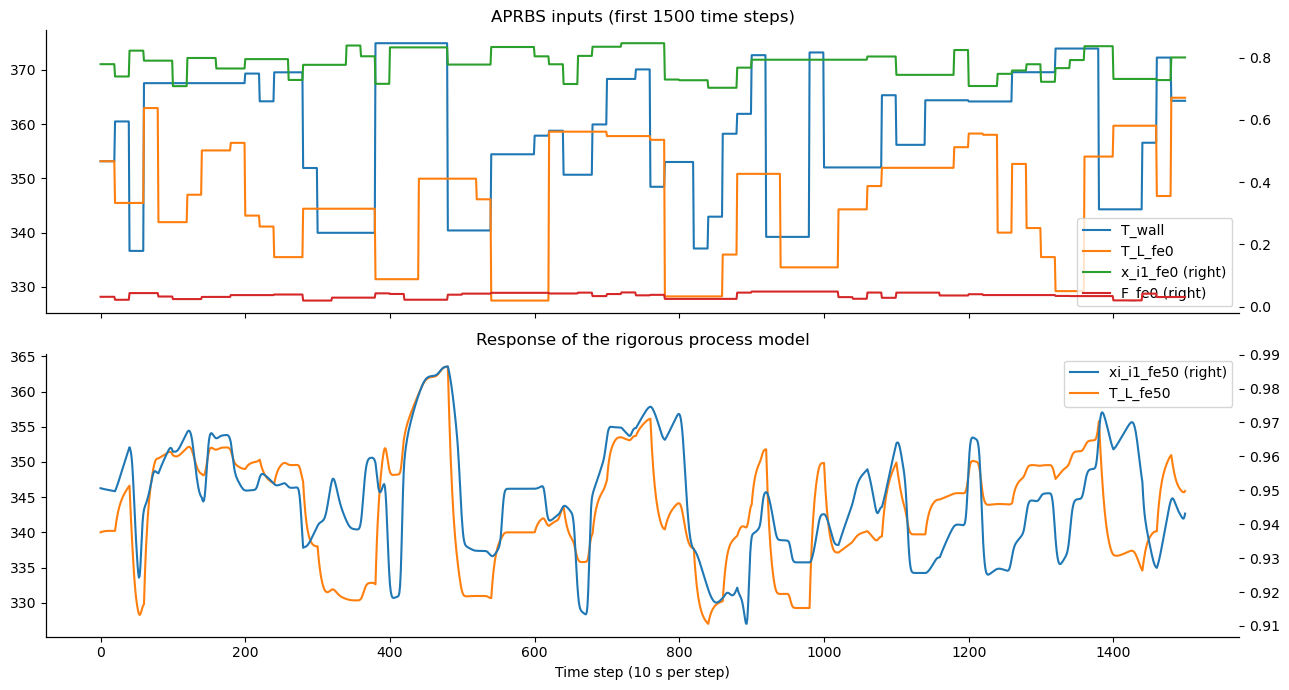

In [15]:
# Plot a short section of the data to show the changing APRBS inputs
# and the delayed, smooth response of the physical process.
N_DISPLAY_STEPS = 1500

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

controls.iloc[:N_DISPLAY_STEPS].plot(
    ax=axes[0],
    secondary_y=["x_i1_fe0", "F_fe0"],
)
outputs.iloc[:N_DISPLAY_STEPS].plot(
    ax=axes[1],
    secondary_y=["xi_i1_fe50"],
)

axes[0].set_title("APRBS inputs (first 1500 time steps)")
axes[1].set_title("Response of the rigorous process model")
axes[1].set_xlabel("Time step (10 s per step)")

plt.tight_layout()
plt.show()


A classic regression model would only connect the inputs at one time step with the outputs at the same time step. This is not sufficient here: the module reacts with a delay, so its current output also depends on its previous state.

## 1. Search design

The search compares two levels of model complexity:

- ARX-LASSO: a linear dynamic model. LASSO can reduce unimportant coefficients through regularization.
- NARX-MLP: a nonlinear dynamic model with one or two hidden neural-network layers.

The lag order is also a hyperparameter. A lag order of 5 means that the model uses the previous five samples of each signal.

| Model | Hyperparameters searched |
|---|---|
| ARX-LASSO | lags `{2, 3, 5}` and five values of `alpha` |
| NARX-MLP | lags `{2, 3, 5}`, two network sizes, two activation functions and three values of `alpha` |

Three expanding time-series validation folds are used. Unlike random cross-validation this preserves the chronological order, since every validation section lies after its corresponding training section.


In [18]:
# Candidate values for the hyperparameter search.
LAG_OPTIONS = [2, 3, 5]
LASSO_ALPHAS = np.logspace(-5, -1, 5)

MLP_HIDDEN_LAYERS = [(64,), (64, 32)]
MLP_ACTIVATIONS = ["relu", "tanh"]
MLP_ALPHAS = [1e-4, 1e-3, 1e-2]

N_CV_SPLITS = 3


def make_scaled_estimator(regressor):
    """Scale the inputs and the single target inside each model fit."""
    scaled_regressor = Pipeline([
        ("scale_inputs", StandardScaler()),
        ("regressor", regressor),
    ])

    return TransformedTargetRegressor(
        regressor=scaled_regressor,
        transformer=StandardScaler(),
    )


def make_regressor(model_name, parameters):
    """Create a fresh LASSO or MLP regressor from a settings dictionary."""
    if model_name == "ARX-LASSO":
        return Lasso(
            alpha=parameters["alpha"],
            max_iter=50_000,
        )

    return MLPRegressor(
        hidden_layer_sizes=parameters["hidden_layers"],
        activation=parameters["activation"],
        solver="adam",
        alpha=parameters["alpha"],
        max_iter=800,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )


## 2. Build the two connected SysIdentPy models

For each target, the other process output is treated as a fifth external input. The target's own history is handled by `ylag`; the four controls and the other output are handled by `xlag`.

`Polynomial(degree=1)` means that SysIdentPy creates the required linear lag terms without additional polynomial interactions. The MLP can still learn nonlinear relationships from these terms.


In [19]:
def get_data_for_one_target(target_index):
    """Return five external inputs and one target for a MISO model."""
    other_target_index = 1 - target_index

    external_inputs = np.column_stack([
        controls.to_numpy(),
        outputs.iloc[:, other_target_index].to_numpy(),
    ])
    target = outputs.iloc[:, [target_index]].to_numpy()

    return external_inputs, target


def fit_two_models(model_name, parameters, n_lags, training_end):
    """Fit one SysIdentPy model for each output up to training_end."""
    fitted_models = []

    # Apply lags 1...n_lags to all five external inputs.
    input_lags = [list(range(1, n_lags + 1)) for _ in range(5)]

    for target_index in range(2):
        external_inputs, target = get_data_for_one_target(target_index)

        model = NARX(
            ylag=n_lags,
            xlag=input_lags,
            model_type="NARMAX",
            basis_function=Polynomial(degree=1),
            base_estimator=make_scaled_estimator(
                make_regressor(model_name, parameters)
            ),
        )

        model.fit(
            X=external_inputs[:training_end],
            y=target[:training_end],
        )
        fitted_models.append(model)

    return fitted_models


def predict_one_step_interval(models, n_lags, start, end):
    """Predict one interval using measured histories before every step."""
    context_start = start - n_lags
    predicted_targets = []

    for target_index, model in enumerate(models):
        external_inputs, target = get_data_for_one_target(target_index)

        prediction = model.predict(
            X=external_inputs[context_start:end],
            y=target[context_start:end],
            steps_ahead=1,
        )

        # Remove the initial history returned by SysIdentPy.
        predicted_targets.append(prediction[n_lags:, 0])

    return np.column_stack(predicted_targets)


## 3. Time-series cross-validation

The validation score is calculated as follows:

1. Compute the RMSE separately for mass fraction and temperature.
2. Divide each RMSE by the standard deviation of its target.
3. Average the two normalized errors.

This prevents the temperature, which has much larger numerical values, from dominating model selection.


In [20]:
def cross_validated_score(model_name, parameters, n_lags):
    """Return the mean balanced RMSE over expanding time-series folds."""
    splitter = TimeSeriesSplit(n_splits=N_CV_SPLITS)
    fold_scores = []

    # Cross-validation uses only the training portion, never the final test set.
    training_indices = np.arange(test_start)

    for fold_number, (train_indices, validation_indices) in enumerate(
        splitter.split(training_indices), start=1
    ):
        training_end = train_indices[-1] + 1
        validation_start = validation_indices[0]
        validation_end = validation_indices[-1] + 1

        models = fit_two_models(
            model_name=model_name,
            parameters=parameters,
            n_lags=n_lags,
            training_end=training_end,
        )

        prediction = predict_one_step_interval(
            models=models,
            n_lags=n_lags,
            start=validation_start,
            end=validation_end,
        )
        truth = outputs.iloc[validation_start:validation_end].to_numpy()

        rmse_per_target = np.sqrt(np.mean((truth - prediction) ** 2, axis=0))
        normalized_rmse = rmse_per_target / np.std(truth, axis=0)
        fold_scores.append(np.mean(normalized_rmse))

    return float(np.mean(fold_scores))


In [21]:
# Run the complete but compact hyperparameter search.
search_rows = []
search_started = time.perf_counter()


def test_candidate(model_name, n_lags, parameters):
    """Evaluate one candidate and store a readable result row."""
    score = cross_validated_score(model_name, parameters, n_lags)

    row = {
        "Model": model_name,
        "Lags": n_lags,
        "Alpha": parameters["alpha"],
        "Hidden layers": parameters.get("hidden_layers", "-"),
        "Activation": parameters.get("activation", "-"),
        "CV balanced RMSE": score,
    }
    search_rows.append(row)

    print(
        f"{model_name:10s} | lags={n_lags} | "
        f"alpha={parameters['alpha']:.0e} | "
        f"layers={parameters.get('hidden_layers', '-')} | "
        f"activation={parameters.get('activation', '-'):4s} | "
        f"score={score:.4f}"
    )


# Linear ARX-LASSO search.
for n_lags in LAG_OPTIONS:
    for alpha in LASSO_ALPHAS:
        test_candidate(
            model_name="ARX-LASSO",
            n_lags=n_lags,
            parameters={"alpha": float(alpha)},
        )

# Nonlinear NARX-MLP search.
for n_lags in LAG_OPTIONS:
    for hidden_layers in MLP_HIDDEN_LAYERS:
        for activation in MLP_ACTIVATIONS:
            for alpha in MLP_ALPHAS:
                test_candidate(
                    model_name="NARX-MLP",
                    n_lags=n_lags,
                    parameters={
                        "hidden_layers": hidden_layers,
                        "activation": activation,
                        "alpha": alpha,
                    },
                )

search_results = pd.DataFrame(search_rows)
search_minutes = (time.perf_counter() - search_started) / 60
print(f"\nSearch completed in {search_minutes:.1f} minutes.")


ARX-LASSO  | lags=2 | alpha=1e-05 | layers=- | activation=-    | score=0.0129
ARX-LASSO  | lags=2 | alpha=1e-04 | layers=- | activation=-    | score=0.0155
ARX-LASSO  | lags=2 | alpha=1e-03 | layers=- | activation=-    | score=0.0313
ARX-LASSO  | lags=2 | alpha=1e-02 | layers=- | activation=-    | score=0.0468
ARX-LASSO  | lags=2 | alpha=1e-01 | layers=- | activation=-    | score=0.1176
ARX-LASSO  | lags=3 | alpha=1e-05 | layers=- | activation=-    | score=0.0114
ARX-LASSO  | lags=3 | alpha=1e-04 | layers=- | activation=-    | score=0.0153
ARX-LASSO  | lags=3 | alpha=1e-03 | layers=- | activation=-    | score=0.0267
ARX-LASSO  | lags=3 | alpha=1e-02 | layers=- | activation=-    | score=0.0466
ARX-LASSO  | lags=3 | alpha=1e-01 | layers=- | activation=-    | score=0.1176
ARX-LASSO  | lags=5 | alpha=1e-05 | layers=- | activation=-    | score=0.0105
ARX-LASSO  | lags=5 | alpha=1e-04 | layers=- | activation=-    | score=0.0136
ARX-LASSO  | lags=5 | alpha=1e-03 | layers=- | activation=-    |

In [23]:
# Select the lowest cross-validation score for each model family.
best_row_indices = search_results.groupby("Model")["CV balanced RMSE"].idxmin()
selected_table = search_results.loc[best_row_indices].reset_index(drop=True)

print("Selected hyperparameters:")
print(selected_table.round(5).to_string(index=False))

# Convert the selected rows back into convenient settings dictionaries.
selected_settings = {}

for _, row in selected_table.iterrows():
    if row["Model"] == "ARX-LASSO":
        parameters = {"alpha": float(row["Alpha"])}
    else:
        parameters = {
            "hidden_layers": row["Hidden layers"],
            "activation": row["Activation"],
            "alpha": float(row["Alpha"]),
        }

    selected_settings[row["Model"]] = {
        "lags": int(row["Lags"]),
        "parameters": parameters,
    }


Selected hyperparameters:
    Model  Lags   Alpha Hidden layers Activation  CV balanced RMSE
ARX-LASSO     5 0.00001             -          -           0.01049
 NARX-MLP     2 0.01000      (64, 32)       tanh           0.03343


## 4. Final autoregressive prediction

The selected candidates are now refitted on the complete 90% training period.

Two predictions are evaluated:

- One step: measured past outputs are available before every prediction.
- Rollout: only the initial output history is measured. Afterwards, both models reuse their own predictions for the entire test period.

For every rollout step, both targets are predicted from the same previous two-output history. Only after both predictions are available is the shared history updated.


In [25]:
def predict_rollout(models, n_lags):
    """Predict the complete test period recursively with both MISO models."""
    output_history = outputs.iloc[test_start - n_lags:test_start].to_numpy().copy()
    control_values = controls.to_numpy()
    predictions = np.zeros((n_test_steps, 2))

    for prediction_index, time_index in enumerate(range(test_start, len(outputs))):
        next_outputs = np.zeros(2)
        control_window = control_values[time_index - n_lags:time_index + 1]

        for target_index, model in enumerate(models):
            other_target_index = 1 - target_index

            # The current placeholder is unused because all external inputs use lags.
            other_output_window = np.append(
                output_history[:, other_target_index],
                np.nan,
            )
            external_input_window = np.column_stack([
                control_window,
                other_output_window,
            ])
            own_output_history = output_history[:, [target_index]]

            prediction = model.predict(
                X=external_input_window,
                y=own_output_history,
                forecast_horizon=1,
            )
            next_outputs[target_index] = prediction[-1, 0]

        predictions[prediction_index] = next_outputs
        output_history = np.vstack([output_history[1:], next_outputs])

    return pd.DataFrame(
        predictions,
        index=outputs.index[test_start:],
        columns=outputs.columns,
    )


In [26]:
# Refit the selected candidates and make the final predictions.
results = {}

for model_name, settings in selected_settings.items():
    print(f"Fitting selected {model_name} ...")

    models = fit_two_models(
        model_name=model_name,
        parameters=settings["parameters"],
        n_lags=settings["lags"],
        training_end=test_start,
    )

    one_step_values = predict_one_step_interval(
        models=models,
        n_lags=settings["lags"],
        start=test_start,
        end=len(outputs),
    )
    one_step = pd.DataFrame(
        one_step_values,
        index=outputs.index[test_start:],
        columns=outputs.columns,
    )

    results[model_name] = {
        "models": models,
        "one_step": one_step,
        "rollout": predict_rollout(models, settings["lags"]),
    }

print("Final model fitting and prediction finished.")


Fitting selected ARX-LASSO ...
Fitting selected NARX-MLP ...
Final model fitting and prediction finished.


## 5. Final evaluation

RMSE and MAE measure prediction errors, where lower values are better. R² measures how much of the target variation is explained, where values closer to 1 are better.


In [27]:
def calculate_metrics(model_name, prediction_type, prediction):
    """Calculate metrics separately for both process outputs."""
    truth = outputs.iloc[test_start:]
    rows = []

    for target_name in outputs.columns:
        actual = truth[target_name]
        predicted = prediction[target_name]

        rows.append({
            "Model": model_name,
            "Prediction": prediction_type,
            "Target": TARGET_LABELS[target_name],
            "RMSE": mean_squared_error(actual, predicted) ** 0.5,
            "MAE": mean_absolute_error(actual, predicted),
            "R2": r2_score(actual, predicted),
        })

    return rows


metric_rows = []

for model_name, model_results in results.items():
    metric_rows += calculate_metrics(
        model_name, "One step", model_results["one_step"]
    )
    metric_rows += calculate_metrics(
        model_name, "Rollout", model_results["rollout"]
    )

metrics = pd.DataFrame(metric_rows)
print(metrics.round(4).to_string(index=False))


    Model Prediction                Target   RMSE    MAE      R2
ARX-LASSO   One step Ethanol mass fraction 0.0003 0.0002  0.9997
ARX-LASSO   One step    Outlet temperature 0.0565 0.0359  1.0000
ARX-LASSO    Rollout Ethanol mass fraction 0.0075 0.0054  0.8136
ARX-LASSO    Rollout    Outlet temperature 1.2282 0.8577  0.9778
 NARX-MLP   One step Ethanol mass fraction 0.0005 0.0003  0.9991
 NARX-MLP   One step    Outlet temperature 0.1888 0.1157  0.9995
 NARX-MLP    Rollout Ethanol mass fraction 0.0191 0.0154 -0.1914
 NARX-MLP    Rollout    Outlet temperature 2.8952 2.3332  0.8767


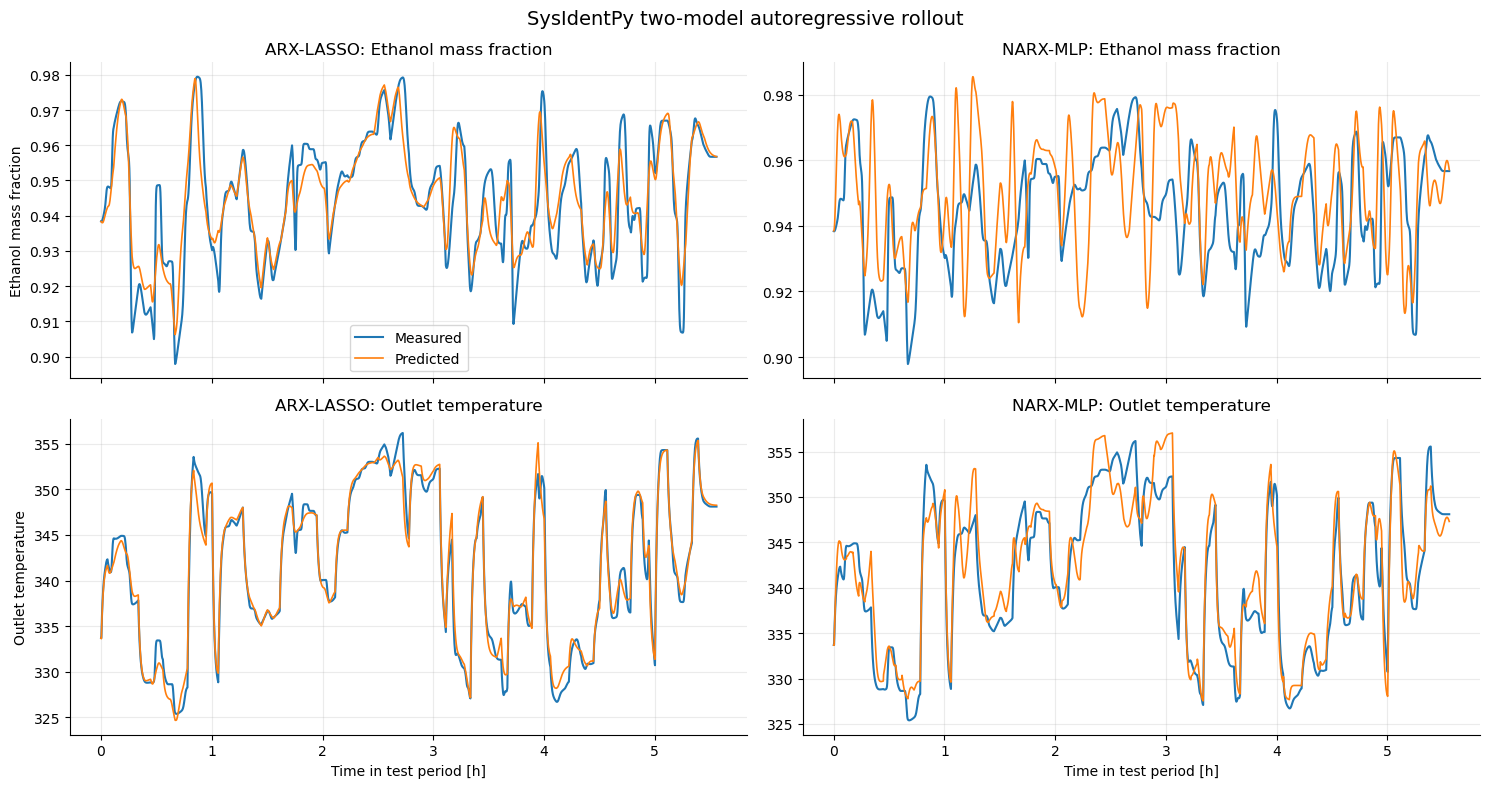

In [28]:
# Plot the complete autoregressive rollout for both targets and models.
truth = outputs.iloc[test_start:]
time_hours = np.arange(n_test_steps) * 10 / 3600
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

for column_index, (model_name, model_results) in enumerate(results.items()):
    rollout = model_results["rollout"]

    for target_index, target_name in enumerate(outputs.columns):
        axis = axes[target_index, column_index]
        axis.plot(time_hours, truth[target_name], label="Measured", linewidth=1.5)
        axis.plot(time_hours, rollout[target_name], label="Predicted", linewidth=1.2)
        axis.set_title(f"{model_name}: {TARGET_LABELS[target_name]}")
        axis.grid(alpha=0.25)

        if target_index == 1:
            axis.set_xlabel("Time in test period [h]")
        if column_index == 0:
            axis.set_ylabel(TARGET_LABELS[target_name])

axes[0, 0].legend()
fig.suptitle("SysIdentPy two-model autoregressive rollout", fontsize=14)
fig.tight_layout()
plt.show()


## 6. Discussion

### Main result

Both models are very accurate when they only predict one step ahead. This shows that the lagged inputs and outputs contain enough information to describe the short-term process dynamics. However, the continuous rollout is the more important test because every prediction is reused at the next step and errors can accumulate.

The linear ARX-LASSO model performs best in this test:

- outlet temperature: RMSE = 1.23 and R² = 0.978
- ethanol mass fraction: RMSE = 0.0075 and R² = 0.81

The NARX-MLP still describes the temperature reasonably well with an R² of 0.88. Its mass-fraction predictions are less stable, however, and the rollout R² is signifcantly worse. The plot shows that its deviations are repeatedly fed back into the model instead of reliably decreasing.

### Interpretation

The best LASSO value for `alpha` is the smallest value in the tested grid. Therefore, only very weak regularization is needed and the selected model behaves similarly to an ordinary linear ARX model. The strong rollout performance suggests that the pervaporation module is approximately linear within the operating range covered by the APRBS data.

For ARX-LASSO, five previous time steps give the best validation result. The MLP selects only two previous steps. A larger history gives the linear model more information, while the additional feedback dimensions do not improve the neural network.

### Final model choice

ARX-LASSO with five lags is selected as the final surrogate model. It has the smallest rollout errors, remains stable over the complete 5.6-hour test period, and is much cheaper to evaluate than the neural network. Fast evaluation is particularly useful for the intended NMPC application.
